# Lab 13

## Section 1: PyTorch 



## Import Torch

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

In [9]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [12]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: cpu


torch.Tensor

In [14]:
sample_input

tensor([[-1.3204,  0.4781,  1.0135,  0.4073,  0.0301, -0.7481,  0.9513,  0.7125,
         -0.1015,  0.1821]])

## Section 2: MNIST Project 
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [16]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [17]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:04<00:00, 2.12MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 99.7kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 901kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<?, ?B/s]


In [18]:
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Visualizing One Image & Understanding Shapes

In [20]:
len(training_data)

60000

In [ ]:
len(test_data)

10000

In [25]:
img, label = training_data[0]

In [27]:
img.shape

torch.Size([1, 28, 28])

In [29]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [31]:
img.squeeze().shape

torch.Size([28, 28])

## Display one Image in MatplotLib

In [34]:
import matplotlib.pyplot as plt

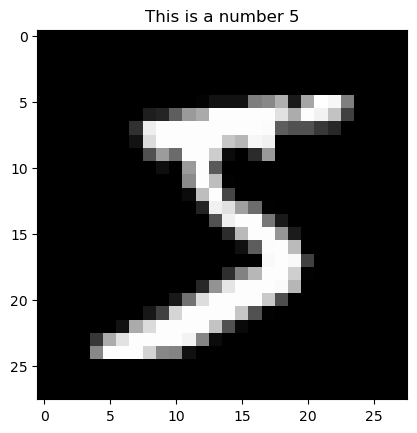

In [35]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"This is a number {label}")
plt.show()

# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [40]:
img, label = training_data[1]

In [42]:
img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

In [45]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            nn.Linear(784, 450), 
            nn.Linear(450, 300), 
            nn.Linear(300, 210), 
            nn.Linear(210, 128), 
            nn.ReLU(),# Activation 
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model = SimpleNet()
print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=450, bias=True)
    (1): Linear(in_features=450, out_features=300, bias=True)
    (2): Linear(in_features=300, out_features=210, bias=True)
    (3): Linear(in_features=210, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [48]:
from torch.utils.data import DataLoader

# Create stacks
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [51]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [53]:
def train():
    model.train()
    
    # Epoch Loop - Train for multiple epochs
    num_epochs = 80
    
    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")
        
        for batch_No, (data, target) in enumerate(train_loader):
            
            output = model(data)
            
            loss = loss_fn(output, target)
            
            # Backpropagation
            optimizer.zero_grad()  # Clear old calculations
            loss.backward()        # Calculate gradients
            optimizer.step()       # Update weights
            
            if batch_No % 100 == 0:
                print(f"Batch {batch_No}: Loss = {loss.item():.4f}")
        
        print(f"Epoch {epoch + 1} completed!")

# Run training

In [ ]:
train()


--- Epoch 1/80 ---
Batch 0: Loss = 2.3082
Batch 100: Loss = 0.3449
Batch 200: Loss = 0.4561
Batch 300: Loss = 0.2875
Batch 400: Loss = 0.4520
Batch 500: Loss = 0.2250
Batch 600: Loss = 0.1738
Batch 700: Loss = 0.1278
Batch 800: Loss = 0.4282
Batch 900: Loss = 0.4062
Epoch 1 completed!

--- Epoch 2/80 ---
Batch 0: Loss = 0.1823
Batch 100: Loss = 0.3547
Batch 200: Loss = 0.2726
Batch 300: Loss = 0.1840
Batch 400: Loss = 0.2909
Batch 500: Loss = 0.2846
Batch 600: Loss = 0.2497
Batch 700: Loss = 0.1560
Batch 800: Loss = 0.1393
Batch 900: Loss = 0.2207
Epoch 2 completed!

--- Epoch 3/80 ---
Batch 0: Loss = 0.1480
Batch 100: Loss = 0.3113
Batch 200: Loss = 0.1706
Batch 300: Loss = 0.2172
Batch 400: Loss = 0.2422
Batch 500: Loss = 0.0890
Batch 600: Loss = 0.2141
Batch 700: Loss = 0.2827
Batch 800: Loss = 0.0715
Batch 900: Loss = 0.2564
Epoch 3 completed!

--- Epoch 4/80 ---
Batch 0: Loss = 0.1123
Batch 100: Loss = 0.1781
Batch 200: Loss = 0.0648
Batch 300: Loss = 0.0706
Batch 400: Loss = 0.3

In [ ]:
def test():
    model.eval() 
    correct = 0
    
    with torch.no_grad(): 
        for data, target in test_loader:
            output = model(data)
            
            prediction = output.argmax(dim=1) 
            
            correct += (prediction == target).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.1%}")

test()

Test Accuracy: 94.6%
